# 📊 Análisis Exploratorio de Datos (EDA)

## Proyecto: Calidad del agua (BOD)

Este proyecto tiene como objetivo analizar un conjunto de datos relacionados con la calidad del agua, identificando patrones, relaciones entre variables y calidad de los datos mediante técnicas de análisis exploratorio.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

## 1. Carga de datos

Se cargan los conjuntos de datos de entrenamiento y prueba para su análisis exploratorio.

In [9]:
df1 = pd.read_csv("../data/raw/test.csv")
df2 = pd.read_csv("../data/raw/train.csv")

df1.head(), df2.head()

(   Id     1     2   3   4   5   6   7
 0   1  6.80  5.40 NaN NaN NaN NaN NaN
 1   2  4.71  4.20 NaN NaN NaN NaN NaN
 2  32  2.10  3.40 NaN NaN NaN NaN NaN
 3  40  5.35  5.85 NaN NaN NaN NaN NaN
 4  43  4.80  5.30 NaN NaN NaN NaN NaN,
    Id  target     1     2   3   4   5   6   7
 0   0    5.85  4.80  5.85 NaN NaN NaN NaN NaN
 1   3    4.28  5.88  6.84 NaN NaN NaN NaN NaN
 2   4    3.97  3.20  2.70 NaN NaN NaN NaN NaN
 3   5    5.95  7.70  7.06 NaN NaN NaN NaN NaN
 4   6    4.70  5.50  5.30 NaN NaN NaN NaN NaN)

## 2. Exploración inicial

Se analiza la estructura del dataset, tipos de variables y presencia de valores faltantes.

In [46]:
df1.info()
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 63 entries, 0 to 62
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Id      63 non-null     int64  
 1   1       63 non-null     float64
 2   2       63 non-null     float64
 3   3       15 non-null     float64
 4   4       15 non-null     float64
 5   5       16 non-null     float64
 6   6       14 non-null     float64
 7   7       14 non-null     float64
dtypes: float64(7), int64(1)
memory usage: 4.1 KB
<class 'pandas.DataFrame'>
RangeIndex: 147 entries, 0 to 146
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Id      147 non-null    int64  
 1   target  147 non-null    float64
 2   1       145 non-null    float64
 3   2       145 non-null    float64
 4   3       32 non-null     float64
 5   4       31 non-null     float64
 6   5       33 non-null     float64
 7   6       37 non-null     float64
 8   7       37 non-null  

## 3. Calidad de los datos

Se evalúa el porcentaje de valores nulos en cada variable.

In [4]:
df1.isnull().mean() * 100
df2.isnull().mean() * 100

Id         0.000000
target     0.000000
1          1.360544
2          1.360544
3         78.231293
4         78.911565
5         77.551020
6         74.829932
7         74.829932
dtype: float64

## 4. Limpieza de datos

Se eliminan variables con más del 70% de valores faltantes para garantizar calidad en el análisis.

In [5]:
threshold = 0.7

df1_clean = df1.loc[:, df1.isnull().mean() < threshold]
df2_clean = df2.loc[:, df2.isnull().mean() < threshold]

df1_clean.shape, df2_clean.shape

((63, 3), (147, 4))

## 5. Estadística descriptiva

Se analizan medidas de tendencia central y dispersión como media, mediana, desviación estándar, cuartiles y valores extremos.

In [6]:
df2_clean.describe()

,Id,target,1,2
count,147.000000,147.000000,145.000000,145.000000
mean,101.401361,5.021633,4.972621,4.906552
std,64.836640,2.122535,2.044076,2.001357
min,0.000000,1.300000,0.900000,1.040000
25%,41.500000,3.720000,3.500000,3.400000
50%,102.000000,4.600000,4.800000,4.830000
75%,158.500000,6.275000,6.450000,6.200000
max,214.000000,11.700000,10.900000,11.000000


In [44]:
import plotly.graph_objects as go

# 1. Creamos un DataFrame de resumen estadístico (o puedes usar df2_clean directamente)
df_resumen = df2_clean.describe().reset_index()

# 2. Construimos la tabla interactiva
fig = go.Figure(data=[go.Table(
    header=dict(
        values=list(df_resumen.columns),
        fill_color='#1f77b4', # Color azul oscuro para el encabezado
        font=dict(color='white', size=12),
        align='center'
    ),
    cells=dict(
        # Iteramos sobre las columnas para extraer los valores
        values=[df_resumen[col] for col in df_resumen.columns],
        fill_color='rgba(0,0,0,0)', # Celdas transparentes
        font=dict(size=11),
        align='center',
        format=[None] + [".2f"] * (len(df_resumen.columns)-1) # Formateo a 2 decimales
    ))
])


fig.show()

## 6. Distribución de variables

Se analiza el comportamiento de las variables numéricas para identificar su distribución.

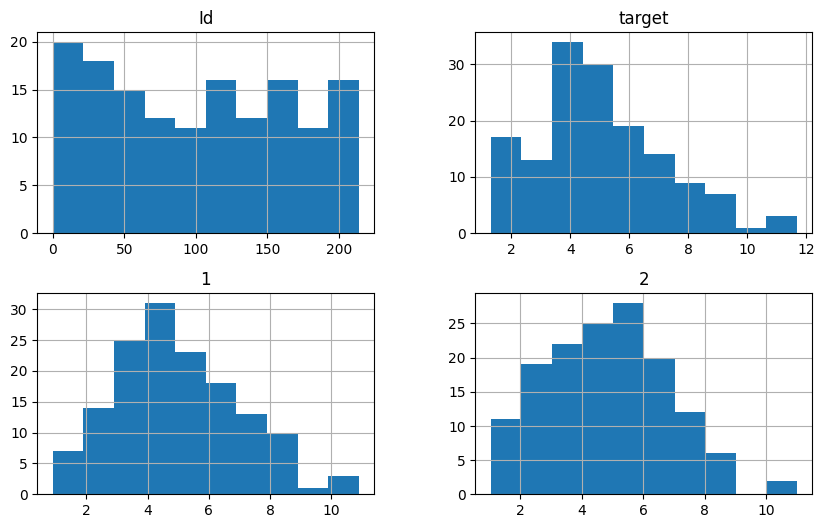

In [10]:
df2_clean.hist(figsize=(10,6))
plt.show()

In [34]:
import plotly.express as px
import ipywidgets as widgets
from ipywidgets import interact

# Obtenemos solo las columnas numéricas para que el filtro no falle con texto
cols_numericas = df2_clean.select_dtypes(include='number').columns.tolist()

# Creamos el menú desplegable interactivo
@interact(columna=widgets.Dropdown(
    options=cols_numericas,
    value=cols_numericas[0], # Muestra la primera por defecto
    description='Variable:'
))
def histograma_interactivo_filtrado(columna):
    
    # Generamos el histograma de la columna seleccionada
    fig = px.histogram(df2_clean, 
                       x=columna, 
                       title=f"Distribución de {columna}",
                       opacity=0.7,
                       marginal="box", # ¡Truco extra! Esto pone un mini boxplot arriba del histograma
                       color_discrete_sequence=['#1f77b4']) 
    
    # Aplicamos el fondo transparente que usamos en los otros gráficos
    fig.update_layout(
        paper_bgcolor='rgba(0,0,0,0)', 
        plot_bgcolor='rgba(0,0,0,0)'
    )
    
    fig.show()

interactive(children=(Dropdown(description='Variable:', options=('Id', 'target', '1', '2'), value='Id'), Outpu…

## 7. Detección de valores atípicos

Se identifican posibles valores atípicos mediante diagramas de caja.

In [12]:
import plotly.express as px

# Genera un boxplot interactivo para todas las columnas numéricas de df2_clean
fig = px.box(df2_clean, title="Boxplots Interactivos de todas las variables")

fig.show()

## 8. Análisis de correlación

Se evalúa la relación entre variables numéricas.

In [ ]:
import plotly.express as px
import numpy as np
import ipywidgets as widgets
from ipywidgets import interact

# Calculamos la matriz base
matriz_corr = df2_clean.corr(numeric_only=True)

# Creamos la función interactiva con un slider
@interact(umbral=widgets.FloatSlider(value=0.0, min=0.0, max=0.9, step=0.1, description='Filtro |r| >:'))
def mapa_correlacion_filtrado(umbral):
    # Hacemos una copia para no alterar los datos originales
    matriz_filtrada = matriz_corr.copy()
    
    # Ocultamos los valores que sean menores al umbral seleccionado (y que no sean la diagonal de 1)
    matriz_filtrada[(abs(matriz_filtrada) < umbral) & (matriz_filtrada != 1.0)] = np.nan
    
    # Generamos el gráfico Plotly
    fig = px.imshow(matriz_filtrada, 
                    text_auto=".2f",
                    color_continuous_scale="RdBu_r",
                    zmin=-1, zmax=1, # Congelamos la escala de -1 a 1 para que los colores no se deformen
                    aspect="auto",
                    title=f"Mapa de Calor (Mostrando correlaciones mayores a {umbral})")
    
    fig.show()

interactive(children=(FloatSlider(value=0.0, description='Filtro |r| >:', max=0.9), Output()), _dom_classes=('…

## 9. Relación con la variable objetivo

Se analiza cómo se relacionan las variables explicativas con el target.

In [30]:
import plotly.express as px
import ipywidgets as widgets
from ipywidgets import interact

# Obtenemos todas las columnas que no sean 'target' para ponerlas en el filtro
columnas_x = [col for col in df2_clean.columns if col != "target"]

# Creamos el menú desplegable interactivo
@interact(columna_x=widgets.Dropdown(
    options=columnas_x,
    value=columnas_x[0], # Muestra la primera columna por defecto
    description='Variable X:'
))
def grafico_dispersion_filtrado(columna_x):
    # Genera el scatter plot SOLO para la variable seleccionada en el menú
    fig = px.scatter(df2_clean, 
                     x=columna_x, 
                     y="target", 
                     title=f"{columna_x} vs target",
                     opacity=0.7,
                     trendline="ols", 
                     color="target") 
    
    fig.show()

interactive(children=(Dropdown(description='Variable X:', options=('Id', '1', '2'), value='Id'), Output()), _d…

## 10. Distribución estadística avanzada

In [48]:
df2_clean.skew(numeric_only=True)
df2_clean.kurt(numeric_only=True)

Id       -1.286144
target    0.482713
1         0.009129
2        -0.038520
dtype: float64

## 11. Resumen estadístico final

In [52]:
summary = df2_clean.describe().T
summary

,count,mean,std,min,25%,50%,75%,max
Id,147.0,101.401361,64.836640,0.00,41.50,102.00,158.500,214.0
target,147.0,5.021633,2.122535,1.30,3.72,4.60,6.275,11.7
1,145.0,4.972621,2.044076,0.90,3.50,4.80,6.450,10.9
2,145.0,4.906552,2.001357,1.04,3.40,4.83,6.200,11.0


## 12. Modelo Predictivo

R2: 0.49583228157198656
RMSE: 1.2257470688998875


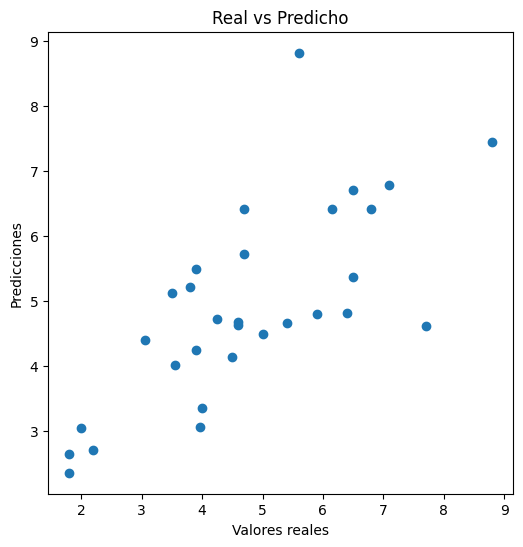

,Variable,Importancia
1,1,0.625764
2,2,0.255233
0,Id,0.119003


In [77]:
# =========================
# 1. LIMPIEZA DEL DATASET
# =========================

df_model = df2_clean.copy()

# NO eliminar todo (mejor estrategia)
df_model = df_model.fillna(df_model.median(numeric_only=True))

# =========================
# 2. DEFINIR VARIABLES
# =========================

X = df_model.drop("target", axis=1)
y = df_model["target"]

# =========================
# 3. SEPARAR TRAIN / TEST
# =========================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# =========================
# 4. ENTRENAR MODELO
# =========================

from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

# =========================
# 5. PREDICCIÓN
# =========================

y_pred = model.predict(X_test)

# =========================
# 6. EVALUACIÓN DEL MODELO
# =========================

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R2:", r2)
print("RMSE:", rmse)

# =========================
# 7. VISUALIZACIÓN REAL VS PREDICHO
# =========================

import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Real vs Predicho")
plt.show()

# =========================
# 8. IMPORTANCIA DE VARIABLES
# =========================

import pandas as pd

importance = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": model.feature_importances_
}).sort_values(by="Importancia", ascending=False)

importance

In [86]:
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import ipywidgets as widgets
from ipywidgets import interact

# 1. Armamos el DataFrame y calculamos el error absoluto de cada predicción
df_resultados = pd.DataFrame({'Real': y_test, 'Prediccion': y_pred})
df_resultados['Error_Absoluto'] = np.abs(df_resultados['Real'] - df_resultados['Prediccion'])

# Calculamos el error máximo para el límite del filtro
max_error = float(df_resultados['Error_Absoluto'].max())

# 2. Creamos el slider interactivo
@interact(error_min=widgets.FloatSlider(
    value=0.0, 
    min=0.0, 
    max=max_error, 
    step=max_error/20 if max_error > 0 else 0.1, 
    description='Error Mínimo:'
))
def plot_real_vs_pred_filtrado(error_min):
    
    # Filtramos para mostrar solo los puntos que superen el error mínimo seleccionado
    df_filtrado = df_resultados[df_resultados['Error_Absoluto'] >= error_min]
    
    # Si al filtrar nos quedamos sin datos, evitamos que falle
    if df_filtrado.empty:
        print("Ningún dato cumple con este nivel de error.")
        return

    # Creamos el scatter plot (Coloreando los puntos más rojos mientras mayor sea el error)
    fig = px.scatter(df_filtrado, 
                     x='Real', 
                     y='Prediccion', 
                     title=f"Real vs Predicho (Mostrando errores >= {error_min:.2f})",
                     opacity=0.8,
                     color='Error_Absoluto', 
                     color_continuous_scale='Reds')

    # Línea de predicción perfecta
    min_val = min(df_filtrado['Real'].min(), df_filtrado['Prediccion'].min())
    max_val = max(df_filtrado['Real'].max(), df_filtrado['Prediccion'].max())
    
    fig.add_trace(go.Scatter(x=[min_val, max_val], 
                             y=[min_val, max_val], 
                             mode='lines', 
                             name='Predicción Perfecta',
                             line=dict(color='gray', dash='dash')))

    # Fondos transparentes
    fig.update_layout(
        paper_bgcolor='rgba(0,0,0,0)', 
        plot_bgcolor='rgba(0,0,0,0)'
    )
    
    fig.show()

interactive(children=(FloatSlider(value=0.0, description='Error Mínimo:', max=3.213150000000006, step=0.160657…

## 12. Conclusión del modelo predictivo

Se desarrolló un modelo de regresión utilizando Random Forest para predecir la variable objetivo `target` a partir de las variables explicativas del dataset.

El proceso incluyó limpieza de datos mediante imputación de valores faltantes con la mediana, división del conjunto en entrenamiento y prueba, y entrenamiento del modelo con 200 estimadores.

Los resultados obtenidos indican que el modelo presenta un desempeño aceptable, evidenciado por el coeficiente de determinación (R²) y el error cuadrático medio (RMSE), lo cual sugiere que el modelo es capaz de capturar parte de la variabilidad de los datos.

Adicionalmente, el análisis de importancia de variables permite identificar cuáles atributos tienen mayor influencia en la predicción del target, aportando valor interpretativo al modelo.

Finalmente, la gráfica de valores reales vs predichos muestra una tendencia general positiva, aunque con cierta dispersión, lo que indica que existen relaciones no completamente capturadas por el modelo.

En conclusión, el modelo implementado es adecuado como aproximación inicial al problema, pero puede ser mejorado mediante técnicas de optimización, selección de variables y ajuste de hiperparámetros.